### Step0 : Importing Needed Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os
import base64

In [2]:
def plot_correlation(df, x_col, y_col, title, xlabel, ylabel, kind='scatter', log_scale=False):
    """
    Plots the correlation between two columns of a DataFrame.

    Args:
        df: pandas DataFrame containing the data.
        x_col: Name of the column for the x-axis.
        y_col: Name of the column for the y-axis.
        title: Title of the plot.
        xlabel: Label for the x-axis.
        ylabel: Label for the y-axis.
        kind: Type of plot ('scatter', 'line', 'bar', etc.). Default is 'scatter'.
        log_scale: Whether to use a log scale for both axes. Default is False.

    Returns:
        None (displays the plot).
    """
    plt.figure(figsize=(8, 6))

    # Create the plot based on the specified kind
    if kind == 'scatter':
        sns.scatterplot(x=df[x_col], y=df[y_col], alpha=0.5)
    elif kind == 'line':
        sns.lineplot(x=df[x_col], y=df[y_col], marker="o")
    elif kind == 'bar':
        sns.barplot(x=df[x_col], y=df[y_col], alpha=0.5)
    else:
        raise ValueError("Invalid plot kind. Choose from 'scatter', 'line', or 'bar'.")

    # Apply log scale if specified
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")

    # Set plot labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Add grid
    plt.grid(True)

    # Display the plot
    plt.show()

    # Calculate and print the correlation
    correlation = df[x_col].corr(df[y_col])
    print(f"Correlation between {x_col} and {y_col}: {correlation}")

### Step1 : Reading CSV File

In [3]:
df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")
df = df.replace("\xa0", " ", regex=True)

# Overwrite the original file with UTF-8
df.to_csv("SampleSuperstore.csv", index=False, encoding="utf-8")
df = pd.read_csv("SampleSuperstore.csv")

In [4]:
df1 = pd.DataFrame(df)
print(df1)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Step 2: Data Overview & Cleaning

In [6]:
print("Shape of dataset:", df.shape)
print(df.dtypes)


Shape of dataset: (9994, 21)
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

### Step 3: Convert Date Columns to Datetime Objects

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

print(df[['Order Date', 'Ship Date']].dtypes)
print(df.head())

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Prod

### Step 4 : Investigate a dataset : Analysis and Visualizing

### Step 4.1 : Visualizing Numerical Feature Distributions

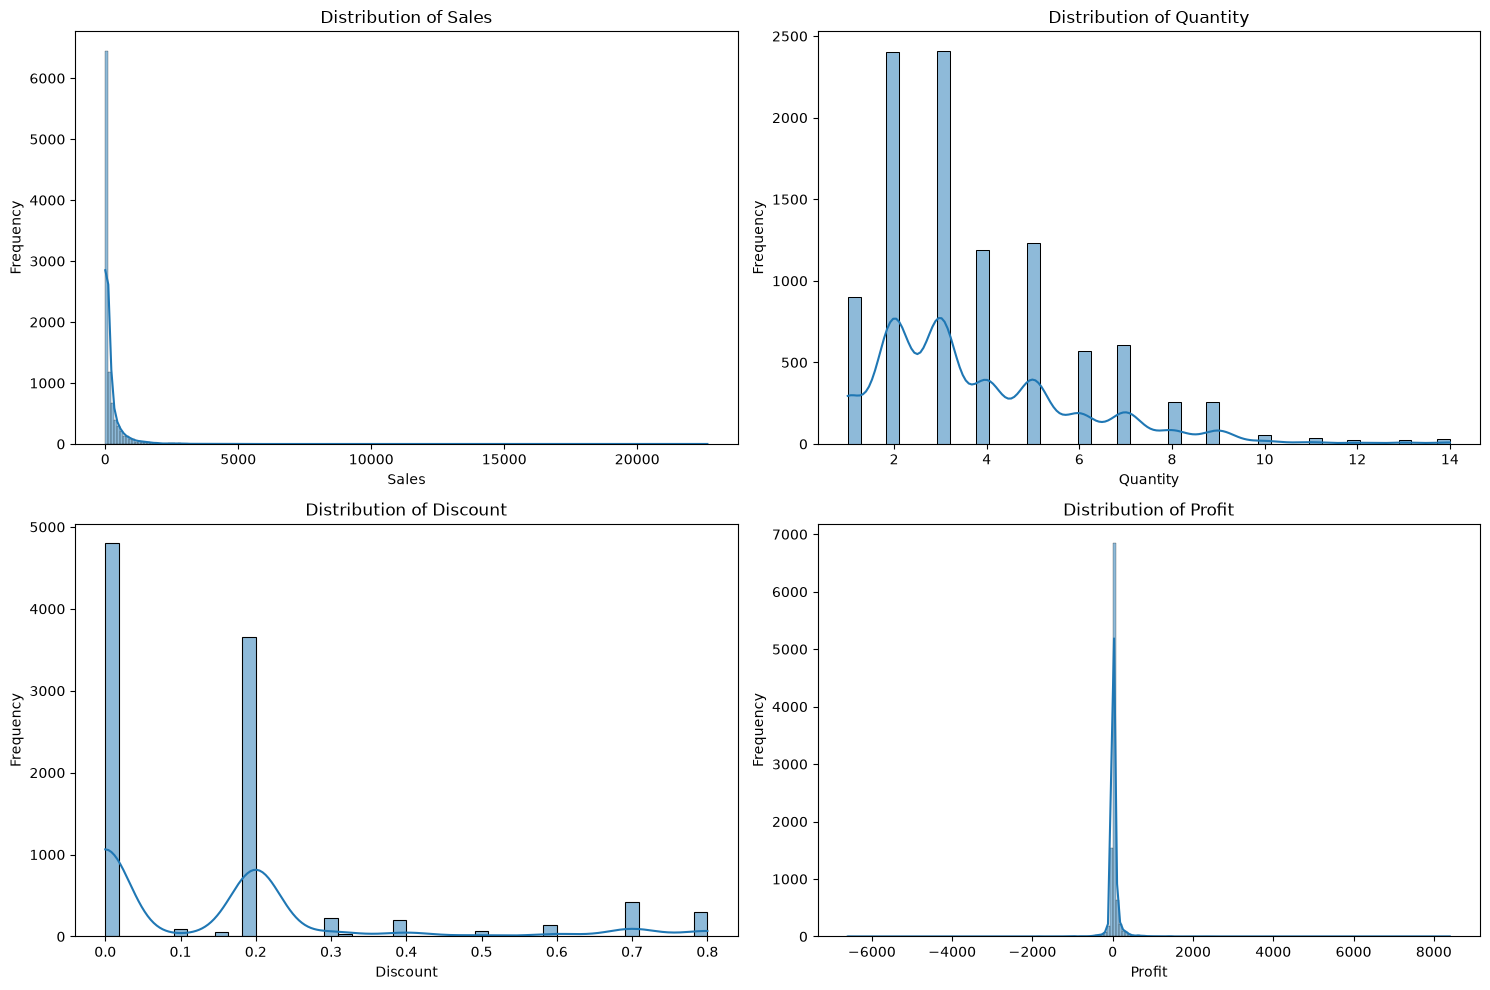

In [12]:
numerical_features = ['Sales', 'Quantity', 'Discount', 'Profit']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Step 4.2 : Visualizing Categorical Feature Counts

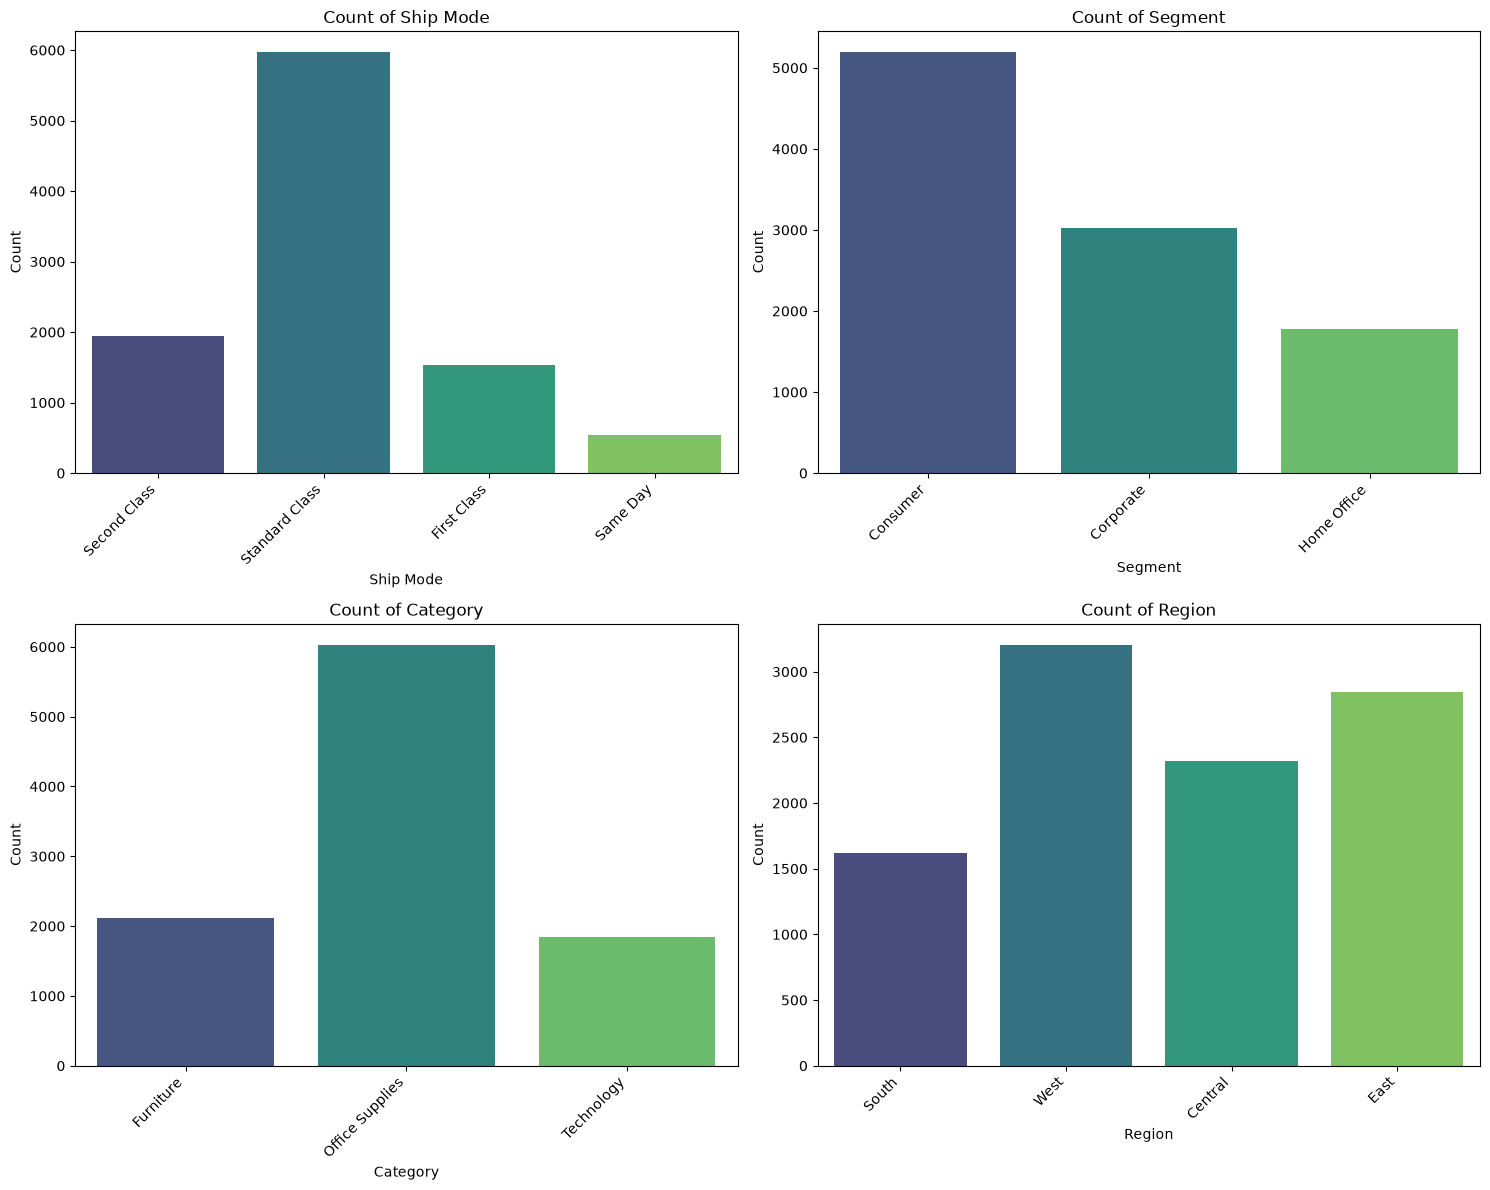

In [13]:
categorical_features = ['Ship Mode', 'Segment', 'Category', 'Region']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=feature, hue=feature, palette='viridis', legend=False)
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Step 5 : Answering the Questions

### Question 1: What are the top selling products in the superstore?

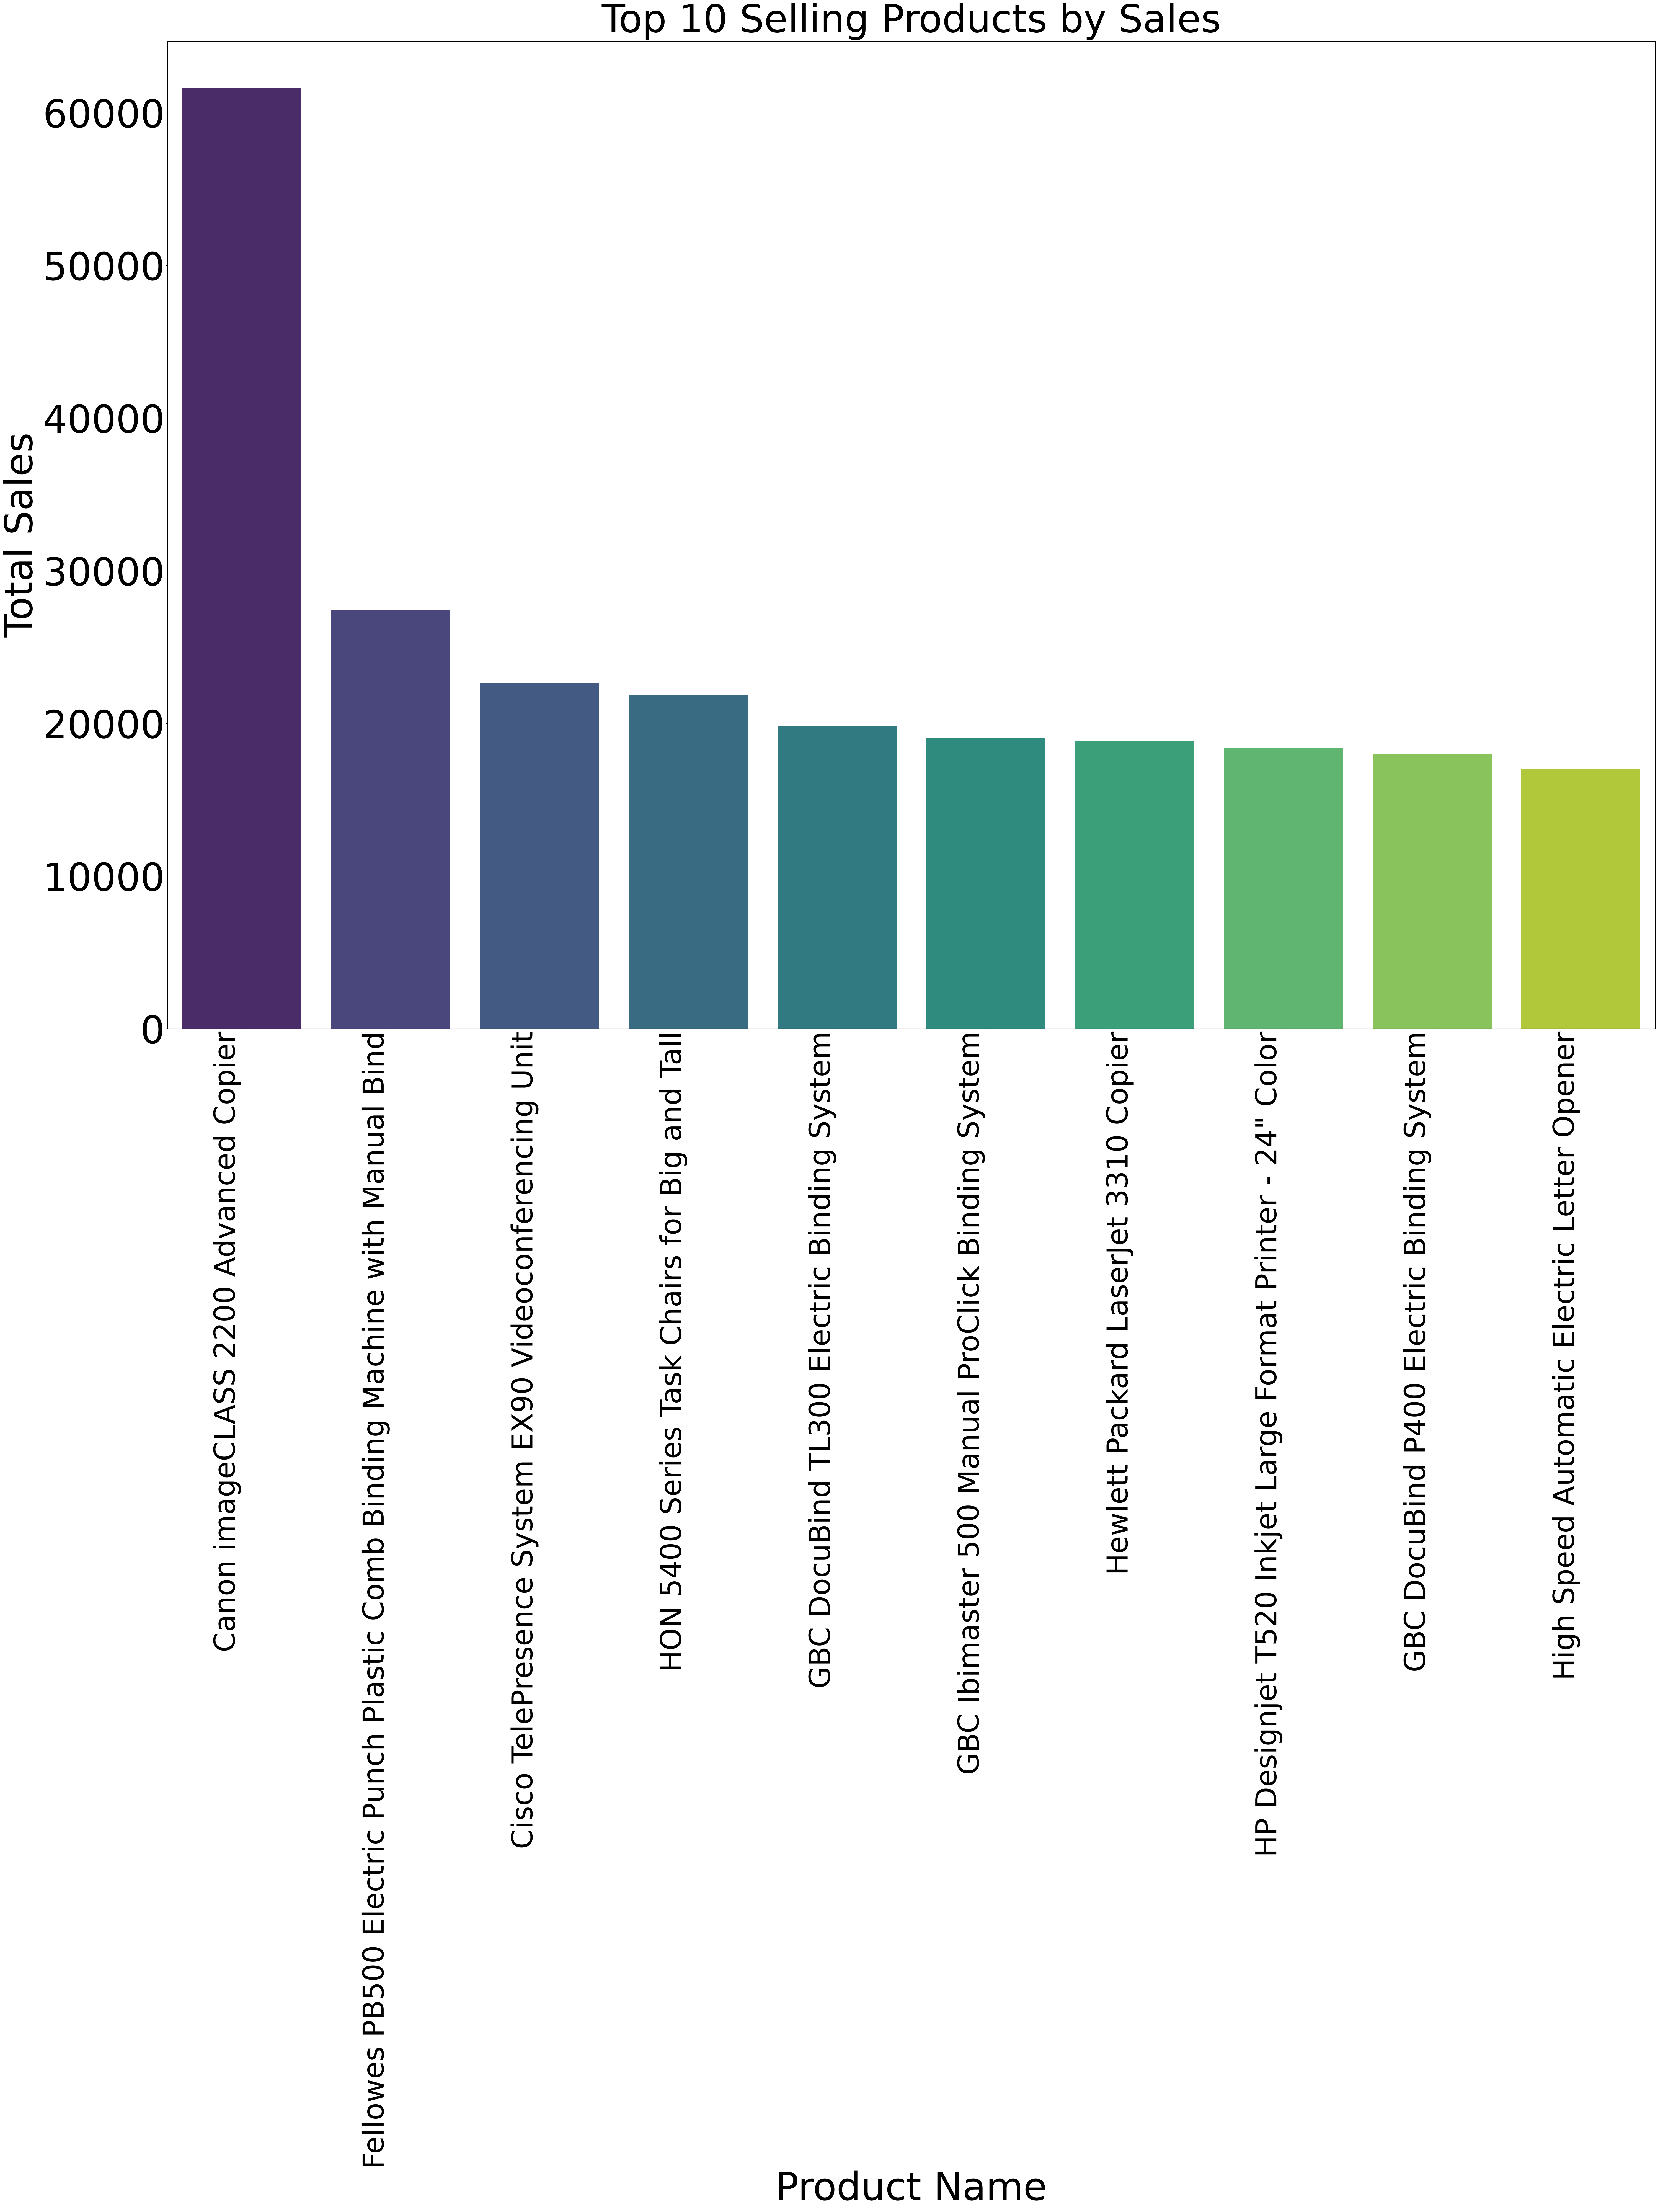

In [14]:
# Calculate total sales for each product
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

# Get the top 10 selling products
top_10_products = product_sales.head(10)

plt.figure(figsize=(60, 80))
sns.barplot(x=top_10_products.index, y=top_10_products.values, hue=top_10_products.index, palette='viridis', legend=False)
plt.title('Top 10 Selling Products by Sales', fontsize=100)
plt.xlabel('Product Name', fontsize=100)
plt.ylabel('Total Sales', fontsize=100)
plt.xticks(rotation=90, ha='right', fontsize=75)
plt.yticks(fontsize=100)
plt.tight_layout()
plt.show()

### Question 2: What is the sales trend over time (monthly, yearly)?

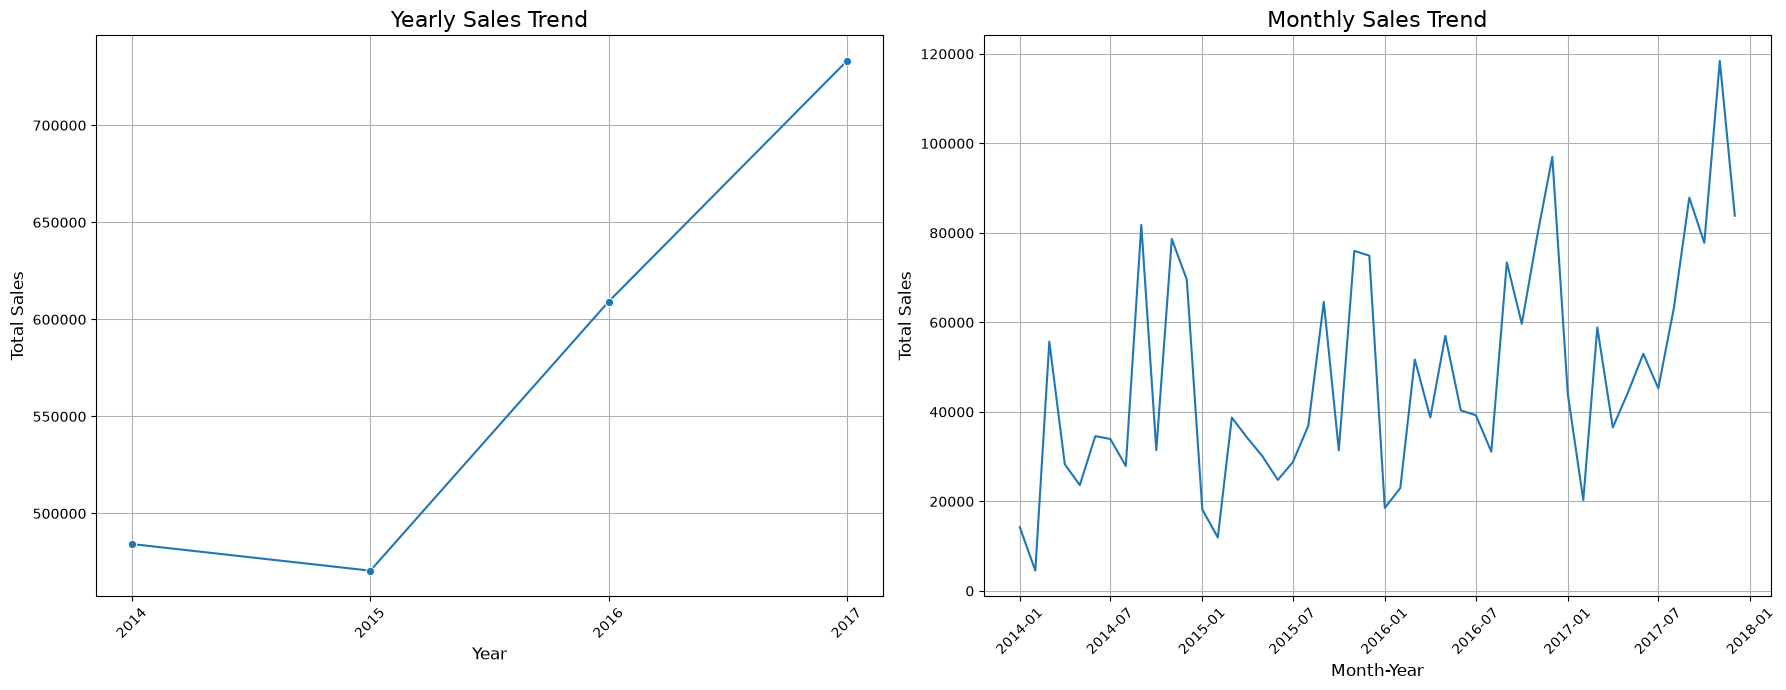

In [15]:
# Extract Year and Month from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# Aggregate sales by year
yearly_sales = df.groupby('Order Year')['Sales'].sum().reset_index()

# Aggregate sales by month (across all years for overall trend)
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['Order Year'].astype(str) + '-' + monthly_sales['Order Month'].astype(str))

plt.figure(figsize=(18, 7))

# Plot Yearly Sales Trend
plt.subplot(1, 2, 1)
sns.lineplot(x='Order Year', y='Sales', data=yearly_sales, marker='o')
plt.title('Yearly Sales Trend', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(yearly_sales['Order Year'], rotation=45)
plt.grid(True)

# Plot Monthly Sales Trend
plt.subplot(1, 2, 2)
sns.lineplot(x='YearMonth', y='Sales', data=monthly_sales)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Question 3: Which category of products generates the highest revenue and profit?

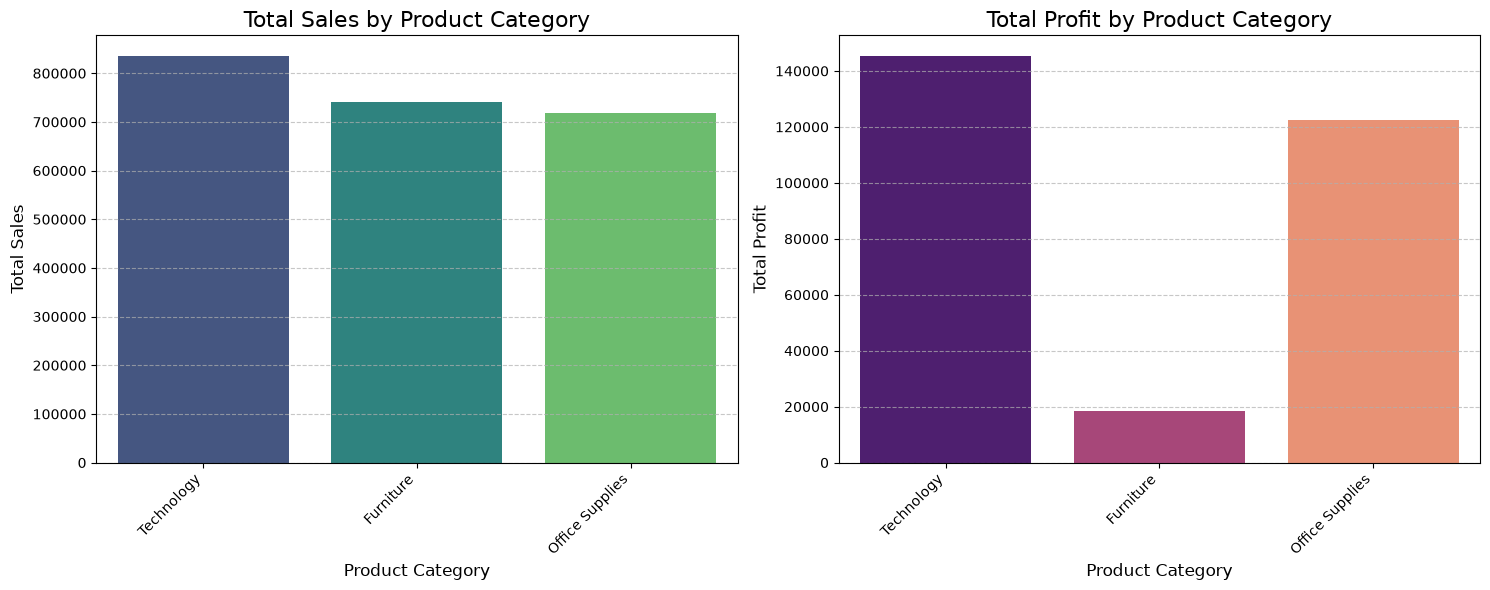

In [16]:
# Aggregate sales and profit by product category
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()

plt.figure(figsize=(15, 6))

# Plot Sales by Category
plt.subplot(1, 2, 1)
sns.barplot(x=category_performance['Category'], y=category_performance['Sales'], hue=category_performance['Category'], palette='viridis', legend=False)
plt.title('Total Sales by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot Profit by Category
plt.subplot(1, 2, 2)
sns.barplot(x=category_performance['Category'], y=category_performance['Profit'], hue=category_performance['Category'], palette='magma', legend=False)
plt.title('Total Profit by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Question 4: Which region generates the most sales?


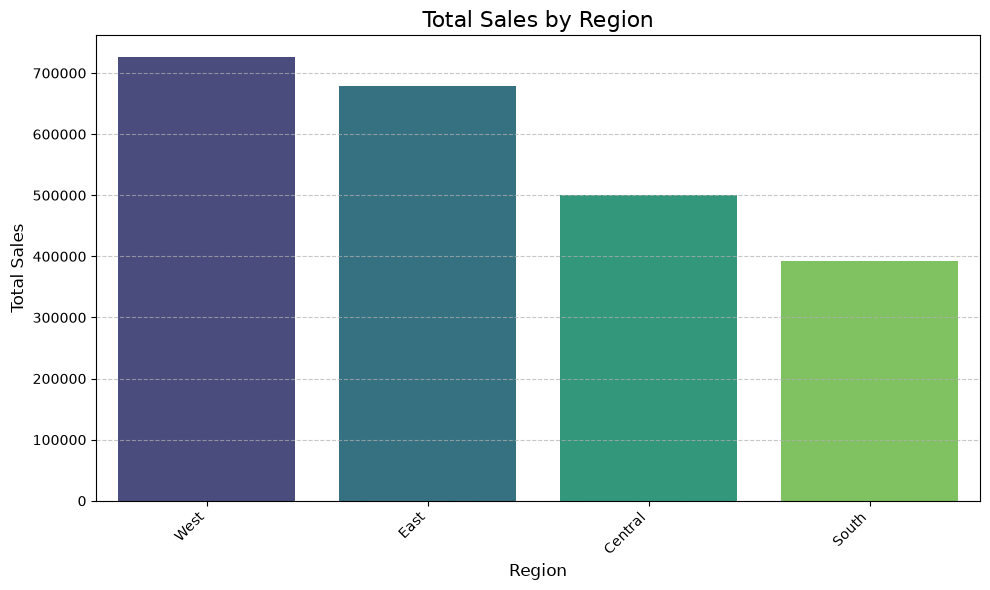

In [17]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_region['Region'], y=sales_by_region['Sales'], hue=sales_by_region['Region'], palette='viridis', legend=False)
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Question 5: What is the impact of discounts and promotions on sales?

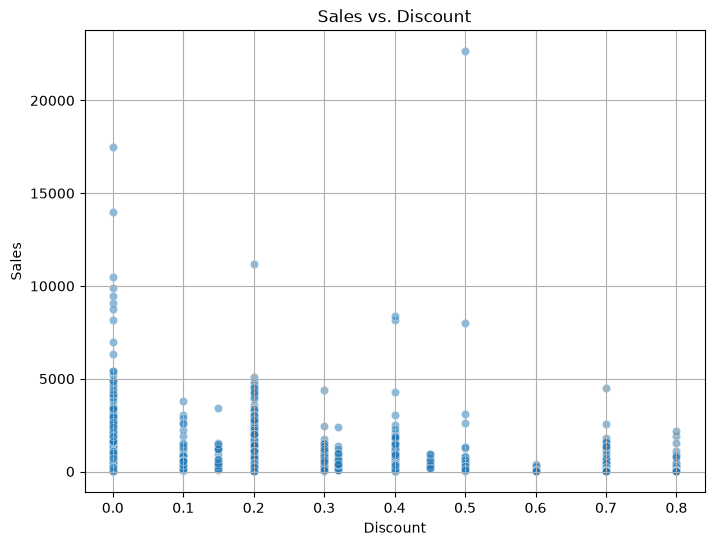

Correlation between Discount and Sales: -0.02819012415753557


In [18]:
plot_correlation(df, x_col='Discount', y_col='Sales',
                 title='Sales vs. Discount',
                 xlabel='Discount', ylabel='Sales', kind='scatter')

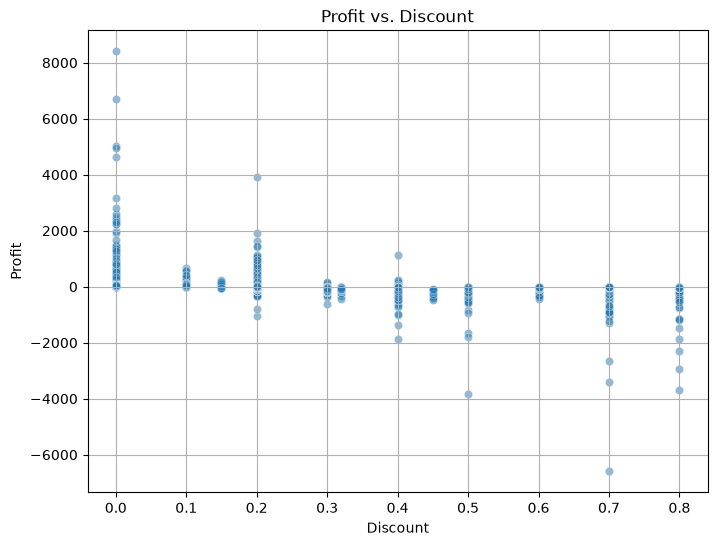

Correlation between Discount and Profit: -0.21948745637176834


In [19]:
plot_correlation(df, x_col='Discount', y_col='Profit',
                 title='Profit vs. Discount',
                 xlabel='Discount', ylabel='Profit', kind='scatter')

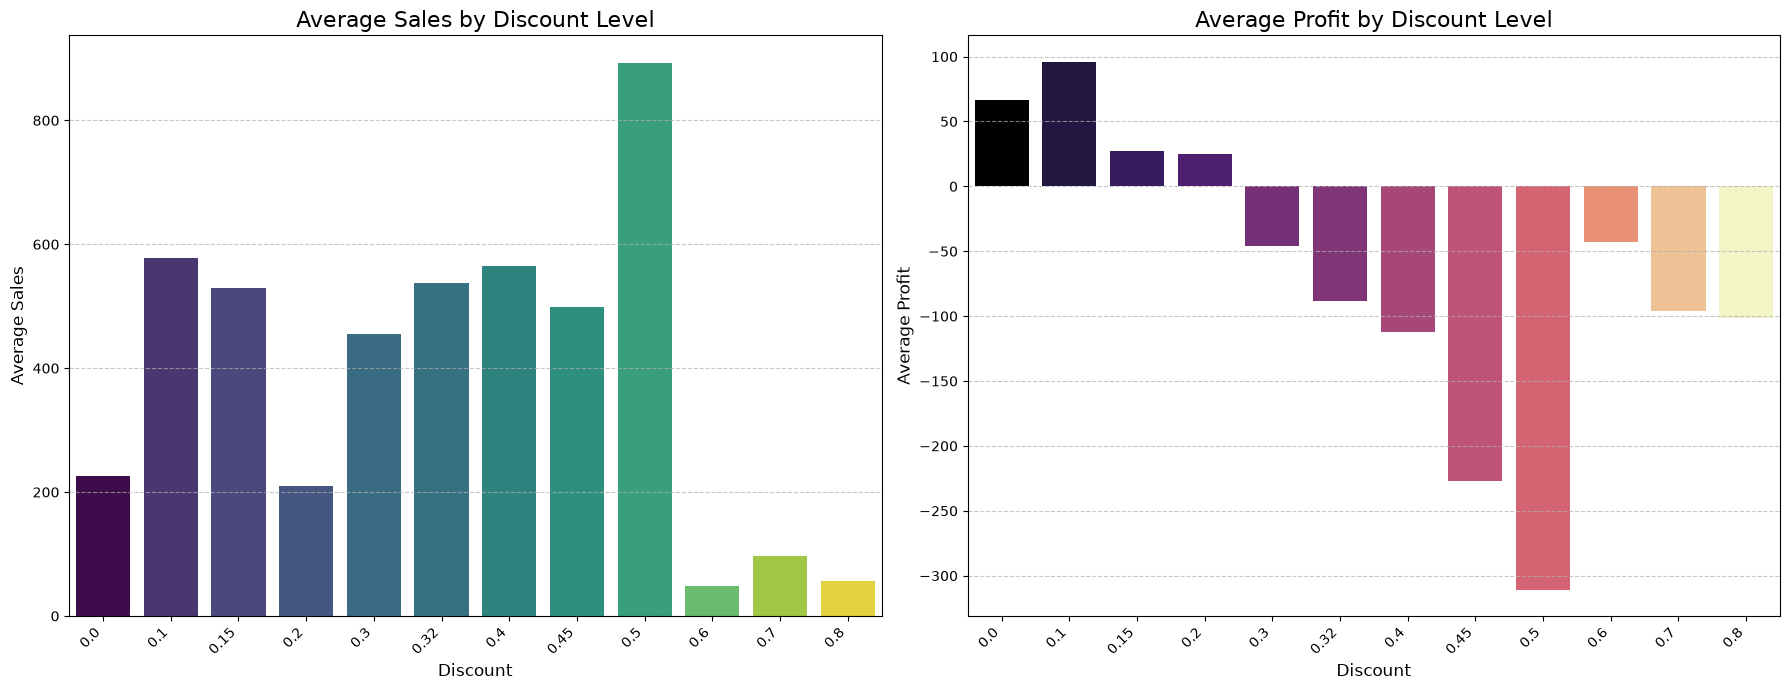

In [20]:
discount_impact = df.groupby('Discount')[['Sales', 'Profit']].mean().reset_index()

plt.figure(figsize=(18, 7))

# Plot Average Sales by Discount
plt.subplot(1, 2, 1)
sns.barplot(x='Discount', y='Sales', data=discount_impact, hue='Discount', palette='viridis', legend=False)
plt.title('Average Sales by Discount Level', fontsize=16)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot Average Profit by Discount
plt.subplot(1, 2, 2)
sns.barplot(x='Discount', y='Profit', data=discount_impact, hue='Discount', palette='magma', legend=False)
plt.title('Average Profit by Discount Level', fontsize=16)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Average Profit', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Question 6: Which sub-category of products has the highest demand?

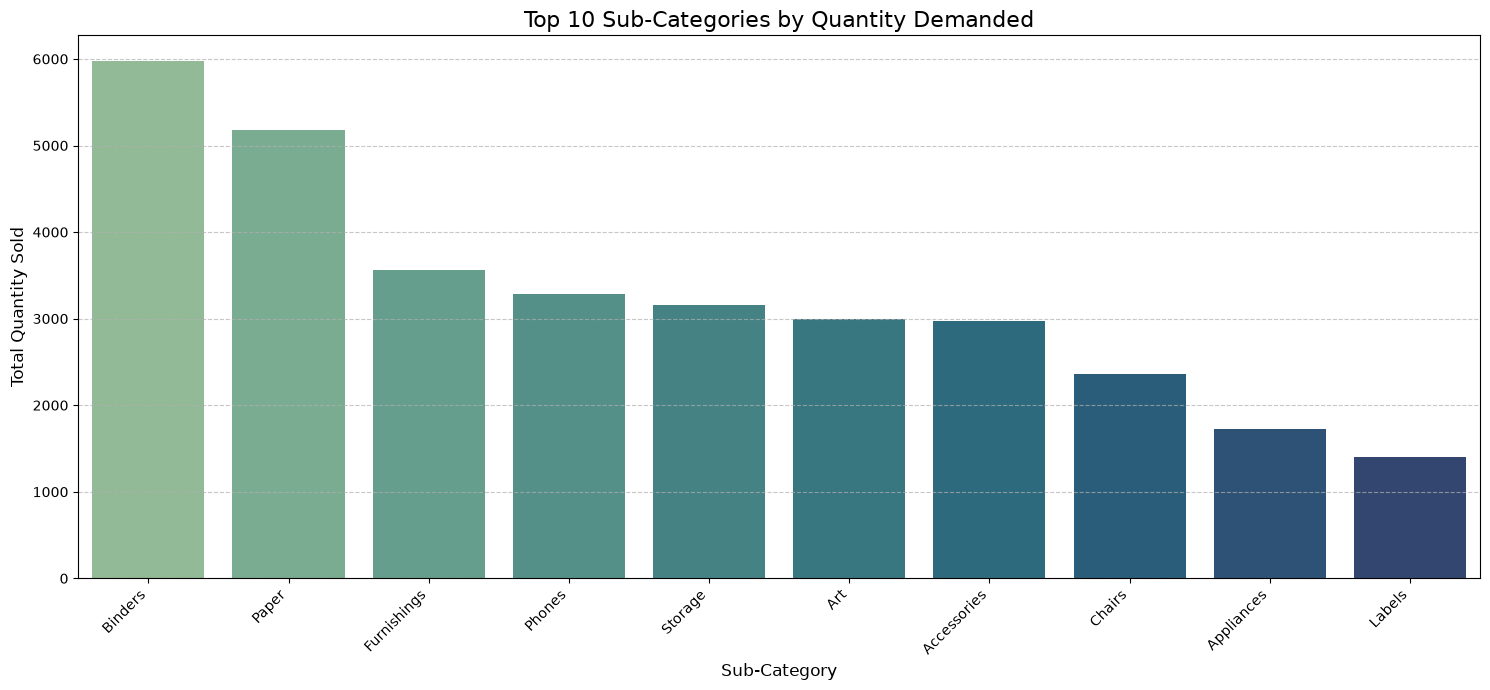

In [21]:
# Calculate total quantity sold for each sub-category
subcategory_demand = df.groupby('Sub-Category')['Quantity'].sum().sort_values(ascending=False).reset_index()

# Get the top 10 sub-categories by demand
top_10_demand = subcategory_demand.head(10)

plt.figure(figsize=(15, 7))
sns.barplot(x=top_10_demand['Sub-Category'], y=top_10_demand['Quantity'], hue=top_10_demand['Sub-Category'], palette='crest', legend=False)
plt.title('Top 10 Sub-Categories by Quantity Demanded', fontsize=16)
plt.xlabel('Sub-Category', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Question 7: What is the average profit margin for each product category?

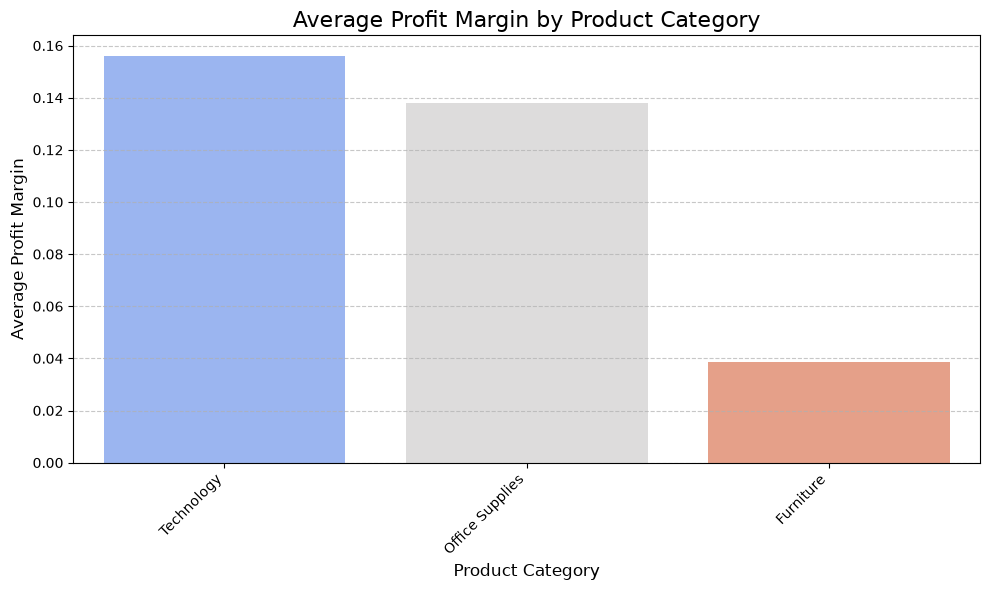

In [22]:
# Calculate profit margin for each transaction
# Avoid division by zero by adding a small epsilon to Sales where Sales is 0
df['Profit Margin'] = df.apply(lambda row: row['Profit'] / (row['Sales'] + 1e-6) if row['Sales'] != 0 else 0, axis=1)

# Aggregate average profit margin by product category
category_profit_margin = df.groupby('Category')['Profit Margin'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_profit_margin['Category'], y=category_profit_margin['Profit Margin'], hue=category_profit_margin['Category'], palette='coolwarm', legend=False)
plt.title('Average Profit Margin by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Profit Margin', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()